# 3.2 - Despesa por Classificacao Funcional - Viamao/RS (2019-2024)

**Fase 6** do roadmap ([`TAREFAS.md`](../TAREFAS.md)). Analisa a **despesa liquidada** por **funcao de governo** (Portaria MP no 42/1999) - o que o municipio faz com o dinheiro, e como isso evoluiu.

**Notas tecnicas (requisitos):**
- Variavel: `vl_liquidacao` - filtro `tipo_operacao == "L"` (Liquidacao).
- Agrupamento: por **funcao**, harmonizada pelo **codigo** `cd_funcao` (os *nomes* variam em caixa/acentuacao entre anos; o codigo e estavel - mesma logica da Secao 3.1).
- Valores **nominais** e **reais** (deflator IPCA, base dez/2024).
- **Per capita** de Saude e Educacao usa populacao do IBGE (dado externo com ressalva de quebra censitaria - ver celula propria).

**Perguntas a responder:** 3.2.a (maior crescimento), 3.2.b (saude/educacao + per capita + cruzamento social), 3.2.c (funcoes-meio vs funcoes-fim).

Dados: **TCE-RS/SIAPC** (nao auditados pelo Tribunal). Externos (IPCA, populacao, indicadores) em [`dados/externos/`](../dados/externos/README.md). Elaboracao propria.

## Setup - imports, caminhos e estilo

Imports e constantes (P5). Caminhos relativos a raiz do projeto.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

RAIZ_PROJETO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARQ_PARQUET = RAIZ_PROJETO / "dados" / "processed" / "viamao_despesa_consolidado.parquet"
ARQ_IPCA = RAIZ_PROJETO / "dados" / "externos" / "ipca_anual_ibge.csv"
ARQ_POP = RAIZ_PROJETO / "dados" / "externos" / "populacao_viamao_ibge.csv"
ARQ_INDIC = RAIZ_PROJETO / "dados" / "externos" / "indicadores_sociais_viamao.csv"
DIR_TABELAS = RAIZ_PROJETO / "output" / "tabelas"
DIR_GRAFICOS = RAIZ_PROJETO / "output" / "graficos"
DIR_TABELAS.mkdir(parents=True, exist_ok=True)
DIR_GRAFICOS.mkdir(parents=True, exist_ok=True)

ANOS = list(range(2019, 2025))  # 2019..2024
ANO_BASE = 2024                 # base do deflator (valores reais em R$ de dez/2024)
FONTE = "Fonte: TCE-RS/SIAPC. Elaboracao propria."

# Paleta categorica colorblind-safe (ordem fixa) + cinza para 'Demais'.
PALETA = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7",
          "#e34948", "#e87ba4", "#eb6834"]
COR_DEMAIS = "#b6b4ad"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
})

def reais(v, casas=0):
    """Formata numero como R$ com separador de milhar (padrao brasileiro)."""
    if pd.isna(v):
        return "\u2014"
    s = f"{v:,.{casas}f}".replace(",", "\u00a7").replace(".", ",").replace("\u00a7", ".")
    return f"R$ {s}"

print("Parquet:", ARQ_PARQUET.name, "| externos:", ARQ_IPCA.name, ARQ_POP.name, ARQ_INDIC.name)

Parquet: viamao_despesa_consolidado.parquet | externos: ipca_anual_ibge.csv populacao_viamao_ibge.csv indicadores_sociais_viamao.csv


## Carga e filtro de Liquidacao

Carrega o consolidado e mantem apenas operacoes de **Liquidacao** (`L`). Confere o total liquidado por ano contra a auditoria da Fase 3 (mesmo sanity check da 3.1 - garante que estamos sobre a mesma base).

In [2]:
df = pd.read_parquet(ARQ_PARQUET)
liq = df[df["tipo_operacao"] == "L"].copy()
print(f"Operacoes de liquidacao: {len(liq):,} de {len(df):,} linhas totais")

TOTAL_LIQ_AUDITORIA = {  # R$ - conferido em etl/README_ETL.md (Fase 3)
    2019: 489_488_993.67, 2020: 554_619_153.77, 2021: 620_202_152.14,
    2022: 683_783_421.80, 2023: 675_417_284.70, 2024: 739_475_339.09,
}
tot_por_ano = liq.groupby("ano")["vl_liquidacao"].sum()
for ano in ANOS:
    assert abs(tot_por_ano[ano] - TOTAL_LIQ_AUDITORIA[ano]) < 0.01, f"{ano} nao bate!"
print("OK - total liquidado por ano confere com a auditoria (dif. < R$ 0,01).")
liq[["ano", "cd_funcao", "ds_funcao", "vl_liquidacao"]].head()

Operacoes de liquidacao: 120,745 de 408,953 linhas totais
OK - total liquidado por ano confere com a auditoria (dif. < R$ 0,01).


,ano,cd_funcao,ds_funcao,vl_liquidacao
1,2019,9,Previdência Social,200.23
3,2019,4,Administração,216.42
5,2019,4,Administração,121.99
7,2019,4,Administração,755.99
9,2019,4,Administração,243.99


## Harmonizacao das funcoes pelo codigo (P1 - transformacao documentada)

Igual aos orgaos na Secao 3.1: os **nomes** das funcoes mudam entre anos - a diferenca aqui e so **caixa e acentuacao** (`SAUDE` vs `Saude`) -, mas o **codigo** `cd_funcao` da Portaria 42/1999 e estavel. Ha **18 codigos** para **36 grafias**; sem harmonizar, cada funcao apareceria partida em duas linhas, somando errado.

**Decisao:** agrupar por `cd_funcao` e rotular com a grafia do **ano mais recente** (ja acentuada). Nenhum valor e criado. **Observacao estrutural importante:** o dataset e da **Prefeitura (Executivo)**, entao **nao ha funcao Legislativa (01), Judiciaria (02) nem Essencial a Justica (03)** - a Camara de Vereadores e ente separado. Isso ja delimita a classificacao meio/fim adiante.

In [3]:
ult = liq.sort_values("ano").groupby("cd_funcao").tail(1)
nome_canonico = ult.set_index("cd_funcao")["ds_funcao"]
liq["funcao"] = liq["cd_funcao"].map(nome_canonico)

variacoes = liq.groupby("cd_funcao")["ds_funcao"].nunique()
print(f"Codigos de funcao: {liq['cd_funcao'].nunique()} | "
      f"grafias de nome: {liq['ds_funcao'].nunique()}")
print(f"Codigos com mais de uma grafia (consolidados): {(variacoes > 1).sum()}")
print("Funcoes presentes (codigo - nome canonico):")
for cd in sorted(nome_canonico.index, key=int):
    print(f"  {cd:>2} - {nome_canonico[cd]}")

Codigos de funcao: 18 | grafias de nome: 36
Codigos com mais de uma grafia (consolidados): 18
Funcoes presentes (codigo - nome canonico):
   4 - ADMINISTRACAO
   6 - SEGURANCA PUBLICA
   8 - ASSISTENCIA SOCIAL
   9 - PREVIDENCIA SOCIAL
  10 - SAUDE
  11 - TRABALHO
  12 - EDUCACAO
  13 - CULTURA
  14 - DIREITOS DA CIDADANIA
  15 - URBANISMO
  16 - HABITACAO
  17 - SANEAMENTO
  18 - GESTAO AMBIENTAL
  20 - AGRICULTURA
  23 - COMERCIO E SERVICOS
  26 - TRANSPORTE
  27 - DESPORTO E LAZER
  28 - ENCARGOS ESPECIAIS


## Deflator IPCA (base dez/2024) - reusa o dado externo da Secao 3.1

Mesma metodologia da 3.1. Fonte do indice: **IBGE/SIDRA** tabela 1737, variavel 69 (*IPCA - variacao acumulada no ano*), em [`dados/externos/ipca_anual_ibge.csv`](../dados/externos/README.md).

$$\text{fator}(Y)=\prod_{k=Y+1}^{2024}\left(1+\tfrac{\text{IPCA}_k}{100}\right),\qquad \text{fator}(2024)=1$$

In [4]:
ipca = pd.read_csv(ARQ_IPCA).set_index("ano")["ipca_acumulado_ano_pct"]
fator = {}
for y in ANOS:
    f = 1.0
    for k in range(y + 1, ANO_BASE + 1):
        f *= 1 + ipca[k] / 100
    fator[y] = f
tab_ipca = pd.DataFrame({
    "IPCA acum. no ano (%)": ipca.reindex(ANOS),
    "Fator p/ base 2024": pd.Series(fator),
})
print(f"Inflacao acumulada 2019->2024 (dez/dez): {(fator[2019]-1)*100:.1f}%")
tab_ipca.style.format({"IPCA acum. no ano (%)": "{:.2f}%", "Fator p/ base 2024": "{:.4f}"})

Inflacao acumulada 2019->2024 (dez/dez): 33.5%


,IPCA acum. no ano (%),Fator p/ base 2024
2019,4.31%,1.3347
2020,4.52%,1.2770
2021,10.06%,1.1602
2022,5.79%,1.0967
2023,4.62%,1.0483
2024,4.83%,1.0000


## Matriz base: despesa liquidada por funcao x ano

Tabela dinamica (funcao x ano) em R$ nominais. Celula vazia = a funcao nao teve liquidacao naquele ano (**ausencia real, nao zero** - P1). E a base de todas as tabelas e graficos a seguir.

In [5]:
piv = liq.pivot_table(index="funcao", columns="ano",
                      values="vl_liquidacao", aggfunc="sum")
piv = piv.reindex(columns=ANOS).sort_values(ANO_BASE, ascending=False)
print("Funcoes x anos (R$ milhoes):")
(piv / 1e6).round(1)

Funcoes x anos (R$ milhoes):


ano,2019,2020,2021,2022,2023,2024
funcao,,,,,,
EDUCACAO,196.0,199.3,241.2,265.7,277.0,306.6
SAUDE,103.6,123.4,129.1,136.2,132.7,165.9
ADMINISTRACAO,54.7,63.7,64.9,80.9,89.3,91.4
URBANISMO,73.2,80.8,111.6,102.4,74.6,67.7
ENCARGOS ESPECIAIS,15.0,32.8,13.2,26.6,29.7,29.9
ASSISTENCIA SOCIAL,17.7,21.3,22.0,22.1,25.0,28.1
TRANSPORTE,9.5,12.1,14.6,19.6,22.4,22.1
COMERCIO E SERVICOS,0.0,NaN,NaN,NaN,NaN,7.6
CULTURA,1.3,2.9,1.4,4.9,8.4,7.4


## Tabela 3.2.A - Despesa liquidada por funcao (nominal, com variacao nominal e real)

Funcoes ordenadas pelo valor de **2024**. `Var.% real` compara 2024 com 2019 trazido a precos de 2024 (`nominal_2019 x fator(2019)`): isola a inflacao.

> **Ressalva de base ininma (P1):** funcoes cuja liquidacao de 2019 foi **inferior a R$ 100 mil** (ex.: *Comercio e Servicos*, *Trabalho*) tem a variacao marcada como **"base ininma"** - o percentual seria matematicamente enorme, mas economicamente sem sentido (partiu de ~zero). Funcoes ausentes em 2019 ou 2024 ficam **n/d**.

In [6]:
LIMIAR_BASE = 100_000  # R$ - abaixo disto em 2019, a variacao % nao e informativa

def var_pct(v_ini, v_fim, fator_ini=1.0):
    if pd.isna(v_ini) or pd.isna(v_fim):
        return np.nan, "n/d"
    base = v_ini * fator_ini
    if v_ini < LIMIAR_BASE:
        return np.nan, "base ininma"
    return (v_fim - base) / base * 100, None

linhas = []
for f in piv.index:
    v19, v24 = piv.loc[f, 2019], piv.loc[f, 2024]
    vn, tn = var_pct(v19, v24)
    vr, tr = var_pct(v19, v24, fator[2019])
    linhas.append([*[piv.loc[f, a] for a in ANOS], vn if tn is None else np.nan,
                   tn, vr if tr is None else np.nan, tr])
tab_a = pd.DataFrame(linhas, index=piv.index,
    columns=[*ANOS, "Var.% nominal", "_tn", "Var.% real", "_tr"])

# Linha TOTAL do municipio (soma ignora NaN -> bate com o total anual).
tot = piv.sum()
tvn = (tot[2024] - tot[2019]) / tot[2019] * 100
tvr = (tot[2024] - tot[2019] * fator[2019]) / (tot[2019] * fator[2019]) * 100
tab_a.loc["TOTAL"] = [*[tot[a] for a in ANOS], tvn, None, tvr, None]

def fmt_var(v, flag):
    if isinstance(flag, str):
        return flag
    return "\u2014" if pd.isna(v) else f"{v:+.1f}%"

disp = tab_a.copy()
disp["Var.% nominal"] = [fmt_var(v, t) for v, t in zip(tab_a["Var.% nominal"], tab_a["_tn"])]
disp["Var.% real"] = [fmt_var(v, t) for v, t in zip(tab_a["Var.% real"], tab_a["_tr"])]
disp = disp.drop(columns=["_tn", "_tr"])
disp.style.format({a: reais for a in ANOS}).set_caption(
    "Tabela 3.2.A - Despesa liquidada por funcao (R$ nominais; variacao nominal e real 2019->2024)")

,2019,2020,2021,2022,2023,2024,Var.% nominal,Var.% real
funcao,,,,,,,,
EDUCACAO,R$ 196.039.179,R$ 199.341.339,R$ 241.225.471,R$ 265.734.738,R$ 276.965.225,R$ 306.619.755,+56.4%,+17.2%
SAUDE,R$ 103.592.936,R$ 123.383.563,R$ 129.098.522,R$ 136.151.351,R$ 132.679.096,R$ 165.903.884,+60.1%,+20.0%
ADMINISTRACAO,R$ 54.673.862,R$ 63.697.641,R$ 64.857.405,R$ 80.933.720,R$ 89.340.311,R$ 91.379.343,+67.1%,+25.2%
URBANISMO,R$ 73.245.632,R$ 80.767.073,R$ 111.561.169,R$ 102.362.597,R$ 74.635.583,R$ 67.659.408,-7.6%,-30.8%
ENCARGOS ESPECIAIS,R$ 15.049.667,R$ 32.825.030,R$ 13.207.845,R$ 26.620.534,R$ 29.668.980,R$ 29.905.991,+98.7%,+48.9%
ASSISTENCIA SOCIAL,R$ 17.702.496,R$ 21.343.132,R$ 21.971.433,R$ 22.074.179,R$ 24.993.887,R$ 28.053.543,+58.5%,+18.7%
TRANSPORTE,R$ 9.460.800,R$ 12.099.657,R$ 14.640.503,R$ 19.645.387,R$ 22.444.245,R$ 22.127.395,+133.9%,+75.2%
COMERCIO E SERVICOS,R$ 540,—,—,—,—,R$ 7.557.102,base ininma,base ininma
CULTURA,R$ 1.314.777,R$ 2.867.884,R$ 1.448.598,R$ 4.928.659,R$ 8.387.193,R$ 7.444.819,+466.2%,+324.3%


## Populacao de Viamao - dado externo com ressalva de quebra censitaria

Denominador do per capita. Fonte: **IBGE** (Estimativas - SIDRA 6579; Censo 2022 - SIDRA 4714), em [`dados/externos/`](../dados/externos/README.md).

> **Atencao (P1):** ha **quebra de serie em 2022**. As estimativas de 2019-2021 usavam projecao do **Censo 2010** e estavam **superestimadas**; o **Censo 2022** recontou **224.112** habitantes (-12,9% frente a estimativa de 2021). E **correcao de medicao, nao perda populacional real**. Consequencia direta: o per capita a partir de 2022 cai sobre uma base menor, entao **parte do salto no per capita em 2022+ vem da revisao do denominador**, nao de mais gasto. O ano de **2023 e interpolacao propria** (IBGE nao publicou estimativa municipal), rotulada na fonte.

In [7]:
pop = pd.read_csv(ARQ_POP).set_index("ano")
pop_serie = pop["populacao"]
print("Populacao residente de Viamao (IBGE):")
for a in ANOS:
    print(f"  {a}: {pop_serie[a]:,} habitantes  ({pop.loc[a, 'tipo_fonte']})")
print(f"\nVariacao aparente 2021->2022: {(pop_serie[2022]/pop_serie[2021]-1)*100:+.1f}% "
      "(quebra censitaria - correcao de medicao)")

Populacao residente de Viamao (IBGE):
  2019: 255,224 habitantes  (estimativa_ibge_base_censo2010)
  2020: 256,302 habitantes  (estimativa_ibge_base_censo2010)
  2021: 257,330 habitantes  (estimativa_ibge_base_censo2010)
  2022: 224,112 habitantes  (censo_2022_contagem)
  2023: 228,078 habitantes  (interpolacao_geometrica_censo2022_estimativa2024)
  2024: 232,113 habitantes  (estimativa_ibge_base_censo2022)

Variacao aparente 2021->2022: -12.9% (quebra censitaria - correcao de medicao)


## Tabela 3.2.B - Gasto per capita em Saude e Educacao

Gasto liquidado dividido pela populacao do ano. Apresento **nominal** e **real** (base dez/2024): o real e o unico comparavel entre anos, pois corrige *preco* (deflator) e *tamanho da populacao* (per capita) ao mesmo tempo. **Leia junto com a ressalva censitaria acima** - o degrau de 2022 e em parte artefato do denominador.

In [8]:
# Saude = codigo 10; Educacao = codigo 12 (nome canonico do ano mais recente).
saude = piv.loc[nome_canonico['10']]
educ = piv.loc[nome_canonico['12']]

pc = pd.DataFrame(index=ANOS)
pc["Populacao"] = pop_serie.reindex(ANOS)
pc["Saude (R$)"] = saude.reindex(ANOS)
pc["Saude per capita nominal"] = pc["Saude (R$)"] / pc["Populacao"]
pc["Saude per capita real"] = [saude[a] * fator[a] / pop_serie[a] for a in ANOS]
pc["Educacao (R$)"] = educ.reindex(ANOS)
pc["Educacao per capita nominal"] = pc["Educacao (R$)"] / pc["Populacao"]
pc["Educacao per capita real"] = [educ[a] * fator[a] / pop_serie[a] for a in ANOS]
tab_b = pc.copy()

print(f"Saude   per capita real: R$ {pc['Saude per capita real'][2019]:.0f} (2019) "
      f"-> R$ {pc['Saude per capita real'][2024]:.0f} (2024)")
print(f"Educacao per capita real: R$ {pc['Educacao per capita real'][2019]:.0f} (2019) "
      f"-> R$ {pc['Educacao per capita real'][2024]:.0f} (2024)")
tab_b.style.format({
    "Populacao": "{:,.0f}",
    "Saude (R$)": reais, "Educacao (R$)": reais,
    "Saude per capita nominal": reais, "Saude per capita real": reais,
    "Educacao per capita nominal": reais, "Educacao per capita real": reais,
}).set_caption("Tabela 3.2.B - Gasto per capita em Saude e Educacao (nominal e real, base 2024)")

Saude   per capita real: R$ 542 (2019) -> R$ 715 (2024)
Educacao per capita real: R$ 1025 (2019) -> R$ 1321 (2024)


,Populacao,Saude (R$),Saude per capita nominal,Saude per capita real,Educacao (R$),Educacao per capita nominal,Educacao per capita real
2019,"255,224",R$ 103.592.936,R$ 406,R$ 542,R$ 196.039.179,R$ 768,R$ 1.025
2020,"256,302",R$ 123.383.563,R$ 481,R$ 615,R$ 199.341.339,R$ 778,R$ 993
2021,"257,330",R$ 129.098.522,R$ 502,R$ 582,R$ 241.225.471,R$ 937,R$ 1.088
2022,"224,112",R$ 136.151.351,R$ 608,R$ 666,R$ 265.734.738,R$ 1.186,R$ 1.300
2023,"228,078",R$ 132.679.096,R$ 582,R$ 610,R$ 276.965.225,R$ 1.214,R$ 1.273
2024,"232,113",R$ 165.903.884,R$ 715,R$ 715,R$ 306.619.755,R$ 1.321,R$ 1.321


## Tabela 3.2.C - Funcoes-meio vs funcoes-fim

Classificacao economica (definicao dos requisitos + Portaria 42/1999):

- **Funcoes-meio** (sustentam a maquina publica): **Administracao (04)**, **Previdencia Social (09)**, **Encargos Especiais (28)**. *(Legislativa, Judiciaria e Essencial a Justica seriam meio, mas nao existem na Prefeitura.)*
- **Funcoes-fim** (entregam servico direto a populacao): Saude, Educacao, Assistencia Social, Urbanismo, Transporte, Cultura, Habitacao, Saneamento, Seguranca Publica, Desporto e Lazer, Trabalho, Direitos da Cidadania, Gestao Ambiental, Agricultura, Comercio e Servicos.

A logica: *meio* = custo de existir e administrar (folha administrativa, divida/encargos, previdencia dos servidores); *fim* = a razao de ser do Estado (servicos finalisticos). Encargos Especiais entram como meio por concentrarem servico da divida e transferencias, nao entrega direta.

In [9]:
COD_MEIO = {"1", "2", "3", "4", "9", "28"}  # presentes: 4, 9, 28
cod_por_funcao = nome_canonico.reset_index().set_index("ds_funcao")["cd_funcao"]
tipo_funcao = {f: ("Funcoes-meio" if cod_por_funcao[f] in COD_MEIO else "Funcoes-fim")
               for f in piv.index}

mf = piv.groupby(tipo_funcao).sum().reindex(["Funcoes-fim", "Funcoes-meio"])
mf.loc["TOTAL"] = mf.sum()
part = mf.divide(mf.loc["TOTAL"], axis=1) * 100

tab_c = mf.copy()
tab_c["Part.% 2019"] = part[2019]
tab_c["Part.% 2024"] = part[2024]
print("Funcoes classificadas como MEIO:",
      [f for f in piv.index if tipo_funcao[f] == "Funcoes-meio"])
tab_c.style.format({**{a: reais for a in ANOS},
                    "Part.% 2019": "{:.1f}%", "Part.% 2024": "{:.1f}%"}).set_caption(
    "Tabela 3.2.C - Funcoes-meio vs funcoes-fim (R$ liquidados e participacao)")

Funcoes classificadas como MEIO: ['ADMINISTRACAO', 'ENCARGOS ESPECIAIS', 'PREVIDENCIA SOCIAL']


ano,2019,2020,2021,2022,2023,2024,Part.% 2019,Part.% 2024
funcao,,,,,,,,
Funcoes-fim,R$ 414.647.902,R$ 452.970.558,R$ 537.133.182,R$ 570.285.944,R$ 550.165.710,R$ 618.190.005,84.7%,83.6%
Funcoes-meio,R$ 74.841.091,R$ 101.648.596,R$ 83.068.970,R$ 113.497.478,R$ 125.251.575,R$ 121.285.334,15.3%,16.4%
TOTAL,R$ 489.488.994,R$ 554.619.154,R$ 620.202.152,R$ 683.783.422,R$ 675.417.285,R$ 739.475.339,100.0%,100.0%


## Tabela 3.2.D - Indicadores sociais de Viamao (dados externos)

Contexto para o cruzamento da 3.2.b (o gasto crescente melhorou os indicadores?). Cada indicador no ano de referencia disponivel, com fonte. Detalhes de proveniencia em [`dados/externos/README.md`](../dados/externos/README.md).

In [10]:
ind = pd.read_csv(ARQ_INDIC)
tab_d = ind.rename(columns={
    "indicador": "Indicador", "ano_ref": "Ano ref.", "viamao": "Viamao",
    "rs": "RS", "brasil": "Brasil", "unidade": "Unidade", "fonte": "Fonte"})
tab_d

,Indicador,Ano ref.,Viamao,RS,Brasil,Unidade,Fonte
0,IDHM,2010,0.717,0.746,0.727,indice_0a1,Atlas Brasil (PNUD/IPEA/FJP) - Censo 2010
1,Taxa de analfabetismo 15 anos ou mais,2022,2.900,3.110,7.000,percentual,IBGE Censo 2022 (SIDRA tabela 9543)
2,Mortalidade infantil,2010,13.440,NaN,NaN,por_mil_nascidos_vivos,IBGE Cidades (indicador municipal)
3,IDESE bloco Educacao,2021,0.558,NaN,NaN,indice_0a1,DEE-RS / FEE (Carta de Conjuntura)


## Grafico 3.2.A - Evolucao das principais funcoes (valores reais)

Seis maiores funcoes de 2024, em **R$ reais (base dez/2024)** - assim a linha mostra crescimento **de verdade**, sem o efeito da inflacao. Linhas com rotulo direto no ultimo ponto.

Grafico salvo: output\graficos\3_2_evolucao_funcoes.png


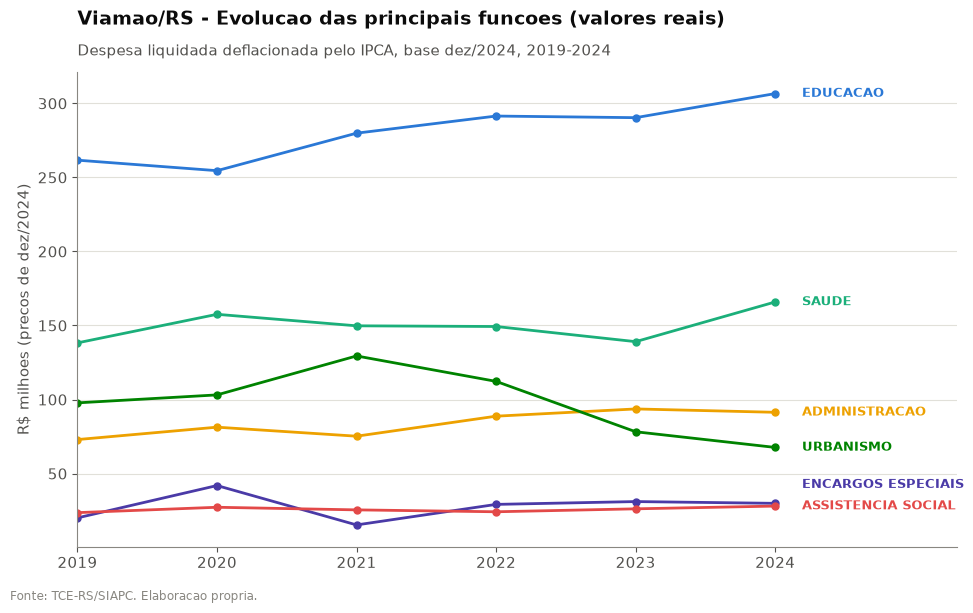

In [11]:
TOP_N = 6
top_f = piv.sort_values(ANO_BASE, ascending=False).head(TOP_N).index
real = pd.DataFrame({a: piv[a] * fator[a] for a in ANOS})  # tudo a precos de 2024

fig, ax = plt.subplots(figsize=(10, 6))
cor_f = {}
for i, f in enumerate(top_f):
    y = (real.loc[f] / 1e6).values
    ax.plot(ANOS, y, marker="o", markersize=5, linewidth=2, color=PALETA[i], label=f)
    cor_f[f] = PALETA[i]

ax.set_xticks(ANOS)
ax.set_xlim(2019, 2025.3)
# Rotulo direto no ultimo ponto, com declutter vertical (evita sobreposicao
# quando duas funcoes terminam em valores proximos, ex.: Encargos e Assistencia).
min_gap = ax.get_ylim()[1] * 0.045
fins = sorted((real.loc[f].iloc[-1] / 1e6, f) for f in top_f
              if not np.isnan(real.loc[f].iloc[-1]))
prev = -1e9
for y, f in fins:
    yy = y if y >= prev + min_gap else prev + min_gap
    ax.text(2024.12, yy, f"  {f}", va="center", fontsize=9,
            color=cor_f[f], fontweight="bold")
    prev = yy
ax.set_ylabel("R$ milhoes (precos de dez/2024)")
ax.set_axisbelow(True)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.text(0, 1.10, "Viamao/RS - Evolucao das principais funcoes (valores reais)",
        transform=ax.transAxes, fontsize=14, fontweight="bold", color=INK)
ax.text(0, 1.035, "Despesa liquidada deflacionada pelo IPCA, base dez/2024, 2019-2024",
        transform=ax.transAxes, fontsize=10.5, color=INK2)
fig.text(0.01, -0.02, FONTE, fontsize=8.5, color=MUTED)
fig.tight_layout()
fig.subplots_adjust(top=0.86)
ARQ_PNG_A = DIR_GRAFICOS / "3_2_evolucao_funcoes.png"
fig.savefig(ARQ_PNG_A, dpi=300, bbox_inches="tight")
print("Grafico salvo:", ARQ_PNG_A.relative_to(RAIZ_PROJETO))
plt.show()

## Grafico 3.2.B - Gasto per capita: Saude e Educacao (barras duplas, reais)

Per capita **real** (base dez/2024) por ano. Barra para Saude e barra para Educacao. **A linha tracejada marca o Censo 2022** - a partir dali o denominador cai ~13% por revisao censitaria, entao o degrau tem componente artificial (ver ressalva da populacao).

Grafico salvo: output\graficos\3_2_per_capita_saude_educacao.png


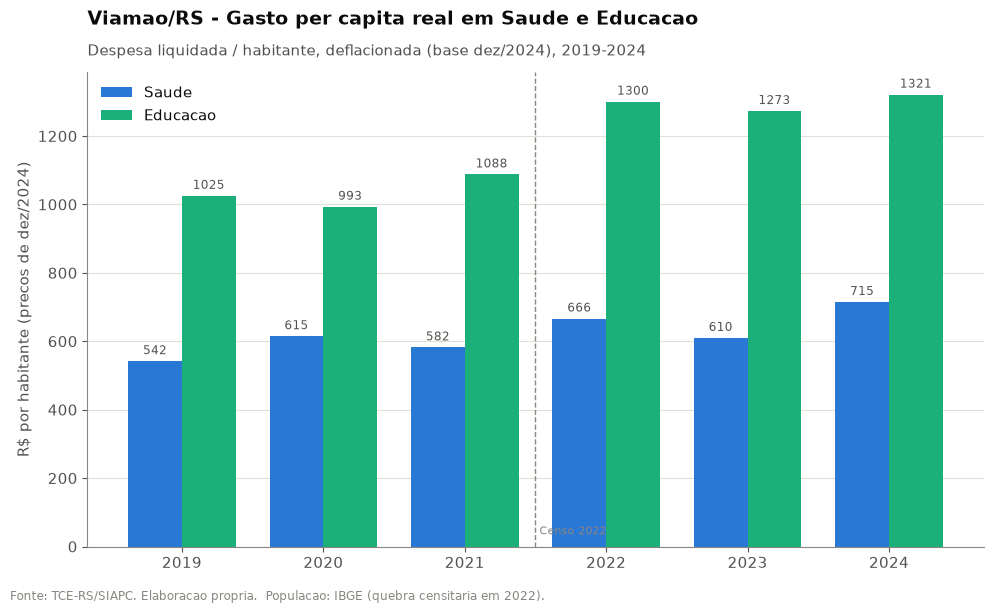

In [12]:
sc = pc["Saude per capita real"].values
ec = pc["Educacao per capita real"].values
x = np.arange(len(ANOS))
w = 0.38
fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - w/2, sc, w, color=PALETA[0], label="Saude")
b2 = ax.bar(x + w/2, ec, w, color=PALETA[1], label="Educacao")
for bars, vals in [(b1, sc), (b2, ec)]:
    for rect, v in zip(bars, vals):
        ax.text(rect.get_x() + rect.get_width()/2, v + 12, f"{v:.0f}",
                ha="center", va="bottom", fontsize=8.5, color=INK2)

ax.axvline(3 - 0.5, color=MUTED, linestyle="--", linewidth=1)
ax.text(3 - 0.5, ax.get_ylim()[1]*0.02, " Censo 2022", fontsize=8, color=MUTED, va="bottom")
ax.set_xticks(x)
ax.set_xticklabels(ANOS)
ax.set_ylabel("R$ por habitante (precos de dez/2024)")
ax.set_axisbelow(True)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.legend(frameon=False, loc="upper left")
ax.text(0, 1.10, "Viamao/RS - Gasto per capita real em Saude e Educacao",
        transform=ax.transAxes, fontsize=14, fontweight="bold", color=INK)
ax.text(0, 1.035, "Despesa liquidada / habitante, deflacionada (base dez/2024), 2019-2024",
        transform=ax.transAxes, fontsize=10.5, color=INK2)
fig.text(0.01, -0.02, FONTE + "  Populacao: IBGE (quebra censitaria em 2022).",
         fontsize=8.5, color=MUTED)
fig.tight_layout()
fig.subplots_adjust(top=0.86)
ARQ_PNG_B = DIR_GRAFICOS / "3_2_per_capita_saude_educacao.png"
fig.savefig(ARQ_PNG_B, dpi=300, bbox_inches="tight")
print("Grafico salvo:", ARQ_PNG_B.relative_to(RAIZ_PROJETO))
plt.show()

## Grafico 3.2.C - Funcoes-meio vs funcoes-fim (participacao 100%)

Barras empilhadas a 100%: quanto do orcamento liquidado foi para servico finalistico (fim) vs sustentacao da maquina (meio), ano a ano. Mostra a prioridade de alocacao ao longo do tempo.

Grafico salvo: output\graficos\3_2_meio_vs_fim.png


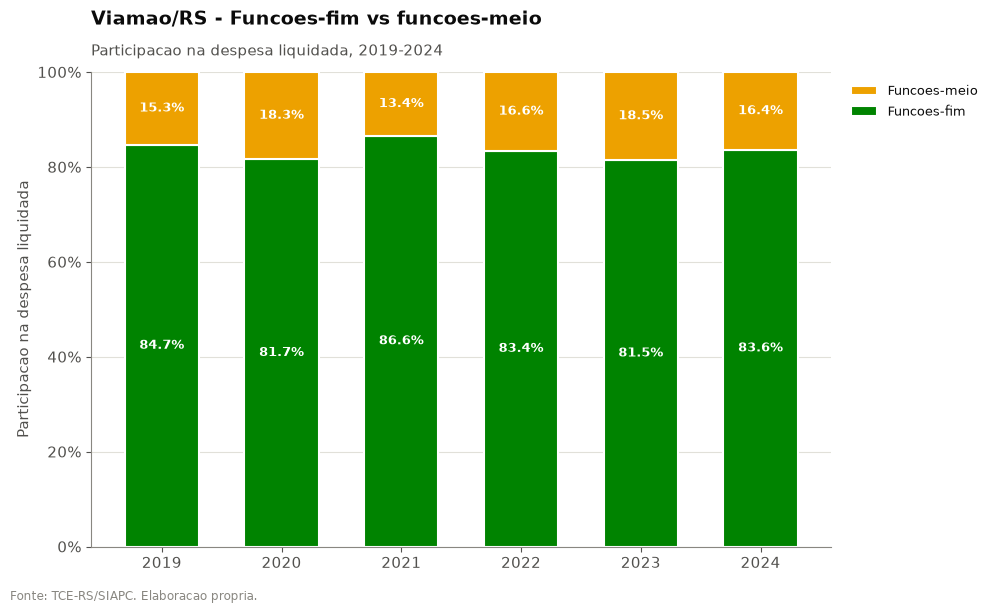

In [13]:
partg = mf.drop(index="TOTAL").divide(mf.loc["TOTAL"], axis=1) * 100
cores_mf = {"Funcoes-fim": PALETA[3], "Funcoes-meio": PALETA[2]}
fig, ax = plt.subplots(figsize=(10, 6))
base = np.zeros(len(ANOS))
for tipo in ["Funcoes-fim", "Funcoes-meio"]:
    vals = partg.loc[tipo].values
    ax.bar(range(len(ANOS)), vals, bottom=base, width=0.62, color=cores_mf[tipo],
           edgecolor="white", linewidth=1.5, label=tipo)
    for xi, (b, v) in enumerate(zip(base, vals)):
        ax.text(xi, b + v/2, f"{v:.1f}%", ha="center", va="center",
                color="white", fontsize=9, fontweight="bold")
    base += vals
ax.set_xticks(range(len(ANOS)))
ax.set_xticklabels(ANOS)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylabel("Participacao na despesa liquidada")
ax.set_axisbelow(True)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.text(0, 1.10, "Viamao/RS - Funcoes-fim vs funcoes-meio",
        transform=ax.transAxes, fontsize=14, fontweight="bold", color=INK)
ax.text(0, 1.035, "Participacao na despesa liquidada, 2019-2024",
        transform=ax.transAxes, fontsize=10.5, color=INK2)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.01, 1), loc="upper left",
          frameon=False, fontsize=9.5)
fig.text(0.01, -0.02, FONTE, fontsize=8.5, color=MUTED)
fig.tight_layout()
fig.subplots_adjust(top=0.86)
ARQ_PNG_C = DIR_GRAFICOS / "3_2_meio_vs_fim.png"
fig.savefig(ARQ_PNG_C, dpi=300, bbox_inches="tight")
print("Grafico salvo:", ARQ_PNG_C.relative_to(RAIZ_PROJETO))
plt.show()

## Exportacao - `output/tabelas/3_2_despesa_por_funcao.xlsx`

Planilha com as tabelas 3.2.A-D, o deflator IPCA e uma aba de Metadados.

In [14]:
from datetime import datetime

ARQ_XLSX = DIR_TABELAS / "3_2_despesa_por_funcao.xlsx"
meta = pd.DataFrame([
    ("Municipio", "Viamao/RS (codigo TCE-RS 63000)"),
    ("Fonte (despesa)", "TCE-RS / SIAPC - Dados Abertos (nao auditados pelo Tribunal)"),
    ("Secao", "3.2 - Classificacao funcional (Portaria MP 42/1999)"),
    ("Variavel", "vl_liquidacao (despesa liquidada)"),
    ("Filtro", "tipo_operacao == 'L' (Liquidacao)"),
    ("Agrupamento", "funcao harmonizada por cd_funcao; rotulo = nome do ano mais recente"),
    ("Periodo", "2019 a 2024"),
    ("Deflator", "IPCA acumulado, base dez/2024 (IBGE/SIDRA tab. 1737 var. 69)"),
    ("Inflacao 2019->2024", f"{(fator[2019]-1)*100:.1f}%"),
    ("Populacao", "IBGE (SIDRA 6579 estimativas; 4714 Censo 2022); 2023 interpolado; quebra censitaria em 2022"),
    ("Indicadores sociais", "Atlas Brasil/PNUD (IDHM), IBGE Censo 2022 (analfabetismo), IBGE Cidades (mortalidade), DEE-RS/FEE (IDESE)"),
    ("Total liquidado 2024 (R$)", round(piv[2024].sum(), 2)),
    ("Gerado por", "notebooks/32_funcional.ipynb"),
    ("Gerado em", datetime.now().isoformat(timespec="seconds")),
], columns=["campo", "valor"])

with pd.ExcelWriter(ARQ_XLSX, engine="openpyxl") as w:
    disp.rename_axis("funcao").to_excel(w, sheet_name="3.2.A_por_funcao")
    tab_b.rename_axis("ano").to_excel(w, sheet_name="3.2.B_per_capita")
    tab_c.rename_axis("tipo").to_excel(w, sheet_name="3.2.C_meio_vs_fim")
    tab_d.to_excel(w, sheet_name="3.2.D_indicadores", index=False)
    tab_ipca.rename_axis("ano").to_excel(w, sheet_name="IPCA_deflator")
    meta.to_excel(w, sheet_name="Metadados", index=False)
print("Tabelas exportadas:", ARQ_XLSX.relative_to(RAIZ_PROJETO))
print("Abas: 3.2.A_por_funcao, 3.2.B_per_capita, 3.2.C_meio_vs_fim, 3.2.D_indicadores, IPCA_deflator, Metadados")

Tabelas exportadas: output\tabelas\3_2_despesa_por_funcao.xlsx
Abas: 3.2.A_por_funcao, 3.2.B_per_capita, 3.2.C_meio_vs_fim, 3.2.D_indicadores, IPCA_deflator, Metadados


## Analise - respostas 3.2.a, 3.2.b e 3.2.c

> Numeros lidos das tabelas acima (despesa: TCE-RS/SIAPC; externos documentados). O texto final do trabalho e redigido a partir daqui.

### 3.2.a - Funcao com maior crescimento
Descontada a inflacao (33,5% no periodo), o municipio cresceu **+13,2% real**. Entre as funcoes de **peso material**, a de maior crescimento real foi **Transporte**, que praticamente **dobrou**: de R$ 9,5 mi (2019) para R$ 22,1 mi (2024) - **+133,9% nominal / +75,2% real**. Em seguida, **Encargos Especiais** (+98,7% / **+48,9% real**, de R$ 15,0 para R$ 29,9 mi). Entre as **tres maiores** funcoes, quem mais cresceu em termos reais foi a **Administracao** (**+25,2% real**), acima de **Saude** (+20,0%) e **Educacao** (+17,2%). 

*Ressalva de honestidade (P1):* algumas funcoes exibem percentuais de tres/quatro digitos (Comercio e Servicos, Trabalho, Cultura) porque **partiram de base ininma em 2019** (~R$ zero) - crescimento matematicamente enorme, economicamente pouco informativo; por isso a Tabela 3.2.A marca esses casos como "base ininma".

### 3.2.b - Saude e Educacao
- **Saude:** R$ 103,6 mi -> R$ 165,9 mi. **+60,1% nominal / +20,0% real.** Per capita real (base 2024): **R$ 542 -> R$ 715/hab**.
- **Educacao:** R$ 196,0 mi -> R$ 306,6 mi. **+56,4% nominal / +17,2% real.** Per capita real: **R$ 1.025 -> R$ 1.321/hab** (Educacao gasta ~o dobro de Saude por habitante - reflexo do peso da rede de ensino infantil/fundamental).
- **Cuidado com o per capita (P1):** o per capita real cresce mais que o agregado real (Saude +32% vs +20%; Educacao +29% vs +17%) **porque a populacao 'cai' de 257 mil (2021) para 224 mil (Censo 2022)**. Esse recuo e **revisao censitaria, nao perda real** - parte do salto per capita de 2022 e artefato do denominador.
- **Cruzamento social (3.2.b):** apesar do gasto real crescente e de indicadores de acesso favoraveis - **analfabetismo 15+ de so 2,90%** (melhor que RS 3,11% e Brasil 7,00%; Censo 2022) e **IDHM 0,717** ('alto', 2010) -, o **IDESE bloco Educacao de Viamao e baixo (0,558 em 2021)**, um dos piores entre municipios de >100 mil habitantes da regiao de Porto Alegre. A leitura economica: **mais gasto nao se converteu automaticamente em melhor resultado/qualidade** - ha uma questao de **eficiencia do gasto**, nao so de volume. *(Cruzamento ilustrativo, nao causal: os indicadores sao de anos distintos - IDHM 2010, IDESE 2021, analfabetismo 2022.)*

### 3.2.c - Funcoes-meio vs funcoes-fim
As **funcoes-fim dominam e sao estaveis**: **84,7% (2019) -> 83,6% (2024)** da despesa liquidada, oscilando entre ~81% e ~87%. As **funcoes-meio** ficam em **15,3% -> 16,4%**, com **picos em 2020 (18,3%) e 2023 (18,5%)**. **Nao ha inversao:** Viamao mantem forte prioridade na entrega de servico direto, coerente com o dominio de Saude+Educacao. Dentro do 'meio' ha recomposicao: **Encargos Especiais quase dobram em termos reais (+48,9%)** enquanto a **Previdencia Social (funcao 09) desaparece da liquidacao em 2024** (presente 2019-2023, ~R$ 5-6 mi/ano) - ausencia real a investigar (possivel reclassificacao do RPPS), nao zero.

### Contexto a explorar no texto final
- **Pandemia (2020-2021):** Saude per capita nominal sobe forte em 2020 (R$ 406 -> R$ 481) e o 'meio' tem pico em 2020 (18,3%).
- **Enchentes no RS (2024):** o efeito nao aparece como pico de Urbanismo na *liquidacao* de 2024 (Urbanismo cai -30,8% real no periodo); **Transporte** e **Assistencia Social** sobem - parte da resposta pode estar em empenhos/2025 ainda nao liquidados (ressalva temporal ja registrada na Fase 3).

---
Fonte: **TCE-RS/SIAPC** (despesa) e fontes externas documentadas. Elaboracao propria.